# Analyse Exploratoire des Données (EDA)



---
### Plan du Notebook
1. Importation des librairies
2. Chargement et aperçu du dataset
3. Dimensions, types et structure
4. Analyse des valeurs manquantes
5. Statistiques descriptives
6. Analyse de la variable cible (Price)
7. Analyse des variables numériques
8. Analyse des variables catégorielles
9. Analyse des corrélations
10. Détection des outliers
11. Analyse bivariée (Price vs Features)
12. Analyse spéciale Piscine (HasPool)
13. Conclusions et recommandations

---
## 1. Importation des Librairies

In [37]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Configuration visuelle
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
sns.set_theme(style='whitegrid', palette='muted')

print('Librairies importées avec succès !')
print(f'   numpy  : {np.__version__}')
print(f'   pandas : {pd.__version__}')

Librairies importées avec succès !
   numpy  : 2.4.0
   pandas : 2.3.3


---
## 2. Chargement et Aperçu du Dataset

In [38]:
# Chargement du dataset
df = pd.read_csv(r"C:\Users\hp\Desktop\housing\Data\processed\clean_data_final.csv")

# Supprimer la colonne Id (non pertinente pour la prédiction)
df = df.drop(columns=['Id'], errors='ignore')

print(f'✅ Dataset chargé : {df.shape[0]} lignes × {df.shape[1]} colonnes')
print()
df.head(10)

✅ Dataset chargé : 2000 lignes × 13 colonnes



,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price,HasPool,PoolArea,PoolQuality,PoolType
0,1360,5,4,3,1970,Downtown,Excellent,No,149919,Yes,21,Low,Outdoor
1,4272,5,4,3,1958,Downtown,Excellent,No,424998,No,0,NaN,NaN
2,3592,2,2,3,1938,Downtown,Good,No,266746,Yes,25,High,Outdoor
3,966,4,2,2,1902,Suburban,Fair,Yes,244020,Yes,33,Low,Indoor
4,4926,1,4,2,1975,Downtown,Fair,Yes,636056,Yes,28,Low,Outdoor
5,3944,1,2,1,1906,Urban,Poor,No,93262,No,0,NaN,NaN
6,3671,1,1,2,1948,Rural,Poor,Yes,448722,Yes,17,Low,Outdoor
7,3419,2,4,1,1925,Suburban,Good,Yes,594893,Yes,40,High,Outdoor
8,630,2,2,1,1932,Rural,Poor,Yes,652878,Yes,30,High,Outdoor
9,2185,3,3,1,2000,Downtown,Poor,No,340375,No,0,NaN,NaN


---
## 3.Dimensions, Types et Structure

In [39]:
print('=' * 60)
print('        INFORMATIONS GÉNÉRALES SUR LE DATASET')
print('=' * 60)
print(f"  Nombre de lignes          : {df.shape[0]}")
print(f"  Nombre de colonnes        : {df.shape[1]}")
print(f"  Taille mémoire            : {df.memory_usage(deep=True).sum() / 1024:.2f} KB")
print('=' * 60)

num_cols = df.select_dtypes(include=['number']).columns.tolist()
cat_cols = df.select_dtypes(include=['object']).columns.tolist()

print(f"\n  Variables NUMÉRIQUES ({len(num_cols)})   : {num_cols}")
print(f"  Variables CATÉGORIELLES ({len(cat_cols)}): {cat_cols}")
print()
print('--- Types de données ---')
print(df.dtypes)
print()
print('--- Valeurs uniques par colonne catégorielle ---')
for col in cat_cols:
    print(f"  {col:<15}: {df[col].dropna().unique().tolist()}")

        INFORMATIONS GÉNÉRALES SUR LE DATASET
  Nombre de lignes          : 2000
  Nombre de colonnes        : 13
  Taille mémoire            : 694.61 KB

  Variables NUMÉRIQUES (7)   : ['Area', 'Bedrooms', 'Bathrooms', 'Floors', 'YearBuilt', 'Price', 'PoolArea']
  Variables CATÉGORIELLES (6): ['Location', 'Condition', 'Garage', 'HasPool', 'PoolQuality', 'PoolType']

--- Types de données ---
Area            int64
Bedrooms        int64
Bathrooms       int64
Floors          int64
YearBuilt       int64
Location       object
Condition      object
Garage         object
Price           int64
HasPool        object
PoolArea        int64
PoolQuality    object
PoolType       object
dtype: object

--- Valeurs uniques par colonne catégorielle ---
  Location       : ['Downtown', 'Suburban', 'Urban', 'Rural']
  Condition      : ['Excellent', 'Good', 'Fair', 'Poor']
  Garage         : ['No', 'Yes']
  HasPool        : ['Yes', 'No']
  PoolQuality    : ['Low', 'High', 'Medium']
  PoolType       : ['Outd

---
## 4. Analyse des Valeurs Manquantes

 Valeurs manquantes détectées :


,Valeurs manquantes,Pourcentage (%)
PoolQuality,984,49.2
PoolType,984,49.2



 Explication : PoolQuality et PoolType sont NaN pour les biens sans piscine (HasPool = "No")
   Biens sans piscine : 984 → ces NaN sont NORMAUX et attendus.


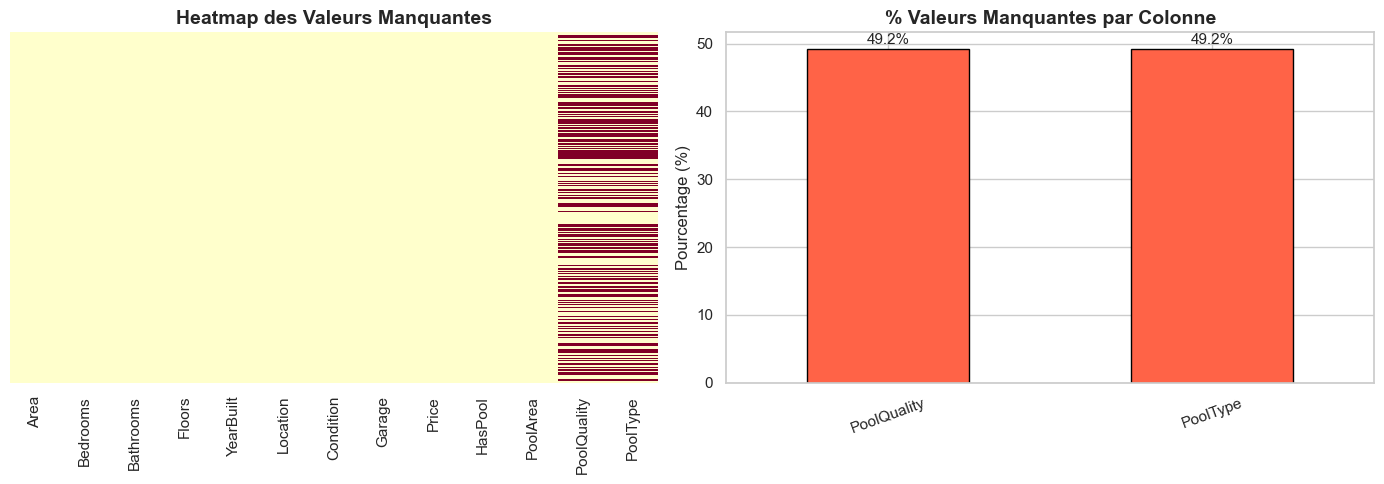

In [40]:
# Tableau des valeurs manquantes
missing = pd.DataFrame({
    'Valeurs manquantes': df.isnull().sum(),
    'Pourcentage (%)':    (df.isnull().sum() / len(df) * 100).round(2)
})
missing_nonzero = missing[missing['Valeurs manquantes'] > 0].sort_values('Pourcentage (%)', ascending=False)

if missing_nonzero.empty:
    print(' Aucune valeur manquante !')
else:
    print(' Valeurs manquantes détectées :')
    display(missing_nonzero)
    print()
    print(' Explication : PoolQuality et PoolType sont NaN pour les biens sans piscine (HasPool = "No")')
    print(f"   Biens sans piscine : {(df['HasPool'] == 'No').sum()} → ces NaN sont NORMAUX et attendus.")

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(df.isnull(), cbar=False, cmap='YlOrRd', ax=axes[0], yticklabels=False)
axes[0].set_title('Heatmap des Valeurs Manquantes', fontsize=14, fontweight='bold')

missing_nonzero['Pourcentage (%)'].plot(kind='bar', ax=axes[1], color='tomato', edgecolor='black')
axes[1].set_title('% Valeurs Manquantes par Colonne', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Pourcentage (%)')
axes[1].tick_params(axis='x', rotation=20)
for bar, v in zip(axes[1].patches, missing_nonzero['Pourcentage (%)'].values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'{v}%', ha='center', va='bottom', fontsize=11)

plt.tight_layout()
plt.show()

Cette visualisation met en évidence la structure des données manquantes dans le dataset. On observe que la majorité des variables sont complètes, sans valeurs manquantes significatives. Cependant, deux variables se distinguent clairement : PoolQuality et PoolType, avec environ 49.2% de valeurs manquantes chacune.

Cela indique que les informations liées aux piscines ne sont pas systématiquement renseignées, probablement parce qu’une grande partie des biens ne possède pas de piscine. Les valeurs manquantes semblent donc structurelles (et non aléatoires).

---
## 5. Statistiques Descriptives

In [41]:
print('--- Statistiques des variables NUMÉRIQUES ---')
display(df[num_cols].describe().round(2))

print('\n--- Statistiques des variables CATÉGORIELLES ---')
display(df[cat_cols].describe())

--- Statistiques des variables NUMÉRIQUES ---


,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Price,PoolArea
count,2000.00,2000.00,2000.00,2000.00,2000.00,2000.00,2000.00
mean,2786.21,3.00,2.55,1.99,1961.45,537676.86,14.95
std,1295.15,1.42,1.11,0.81,35.93,276428.85,16.82
min,501.00,1.00,1.00,1.00,1900.00,50005.00,0.00
25%,1653.00,2.00,2.00,1.00,1930.00,300098.00,0.00
50%,2833.00,3.00,3.00,2.00,1961.00,539254.00,10.00
75%,3887.50,4.00,4.00,3.00,1993.00,780086.00,30.00
max,4999.00,5.00,4.00,3.00,2023.00,999656.00,49.00



--- Statistiques des variables CATÉGORIELLES ---


,Location,Condition,Garage,HasPool,PoolQuality,PoolType
count,2000,2000,2000,2000,1016,1016
unique,4,4,2,2,3,2
top,Downtown,Fair,No,Yes,Low,Indoor
freq,558,521,1038,1016,353,522


---
## 6.Analyse de la Variable Cible : PRICE

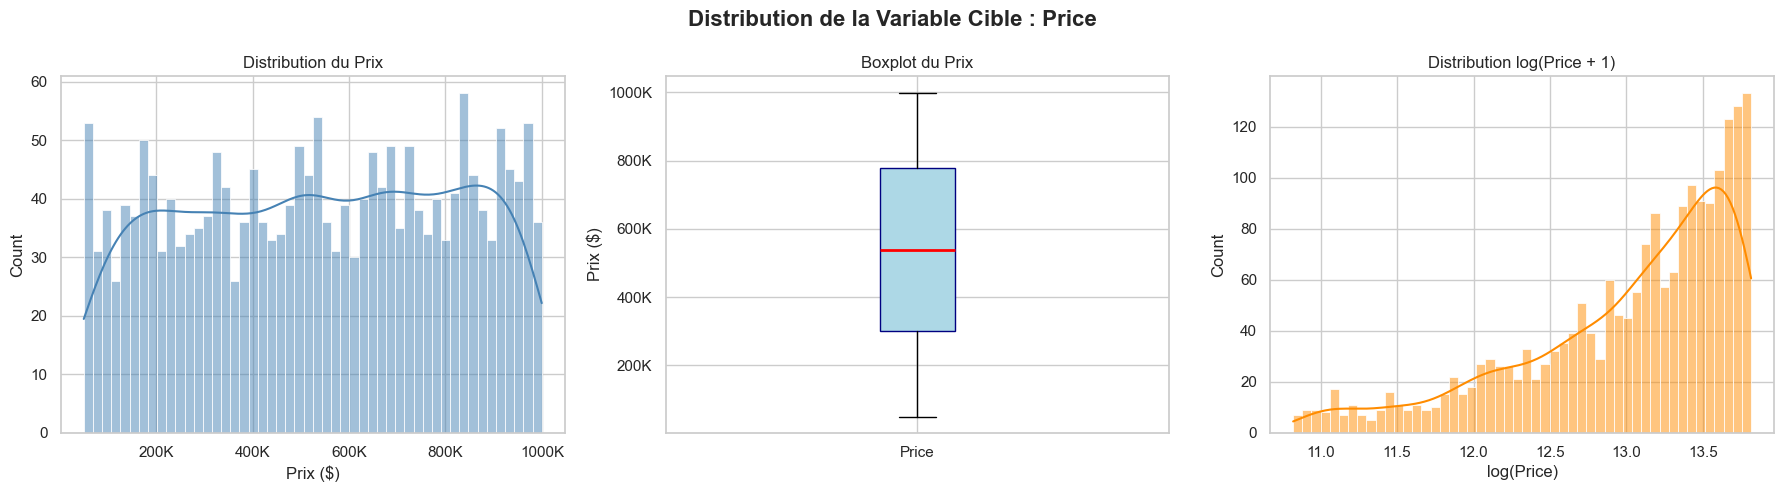


📐 Métriques de distribution :
   Moyenne     : $537,677
   Médiane     : $539,254
   Écart-type  : $276,429
   Min         : $50,005
   Max         : $999,656
   Skewness    : -0.0644
   Kurtosis    : -1.2025

   Test Shapiro-Wilk → stat=0.9456, p=0.000001
   → Distribution NON normale (p < 0.05) — Log-transform recommandée 


In [42]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Distribution de la Variable Cible : Price', fontsize=16, fontweight='bold')

# Histogramme + KDE
sns.histplot(df['Price'], bins=50, kde=True, color='steelblue', ax=axes[0])
axes[0].set_title('Distribution du Prix')
axes[0].set_xlabel('Prix ($)')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}K'))

# Boxplot
axes[1].boxplot(df['Price'], patch_artist=True,
                boxprops=dict(facecolor='lightblue', color='navy'),
                medianprops=dict(color='red', linewidth=2))
axes[1].set_title('Boxplot du Prix')
axes[1].set_ylabel('Prix ($)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}K'))
axes[1].set_xticklabels(['Price'])

# Log-transformation
sns.histplot(np.log1p(df['Price']), bins=50, kde=True, color='darkorange', ax=axes[2])
axes[2].set_title('Distribution log(Price + 1)')
axes[2].set_xlabel('log(Price)')

plt.tight_layout()

plt.show()

# Métriques
print('\n📐 Métriques de distribution :')
print(f"   Moyenne     : ${df['Price'].mean():,.0f}")
print(f"   Médiane     : ${df['Price'].median():,.0f}")
print(f"   Écart-type  : ${df['Price'].std():,.0f}")
print(f"   Min         : ${df['Price'].min():,.0f}")
print(f"   Max         : ${df['Price'].max():,.0f}")
print(f"   Skewness    : {df['Price'].skew():.4f}")
print(f"   Kurtosis    : {df['Price'].kurtosis():.4f}")

# Test de normalité
stat, p = stats.shapiro(df['Price'].sample(200, random_state=42))
print(f"\n   Test Shapiro-Wilk → stat={stat:.4f}, p={p:.6f}")
print(f"   → Distribution {'NON normale (p < 0.05) — Log-transform recommandée ' if p < 0.05 else 'normale'}")

La distribution du prix montre une dispersion importante des valeurs, allant d’environ 50 000 à 1 000 000. La moyenne (~537 677) et la médiane (~539 254) sont très proches, ce qui indique une distribution globalement équilibrée.

Cependant, le test de normalité de Shapiro-Wilk (p ≈ 0.000001) confirme que la distribution n’est pas normale, malgré une skewness proche de zéro (-0.0644). La kurtosis négative (-1.20) indique une distribution plus aplatie que la normale.

La transformation logarithmique log(Price + 1) améliore nettement la distribution, la rendant plus symétrique et plus adaptée aux modèles de régression.

Conclusion :

Variable cible non normale

Log-transform recommandée pour stabiliser la variance et améliorer les performances des modèles

---
## 7.Analyse des Variables Numériques

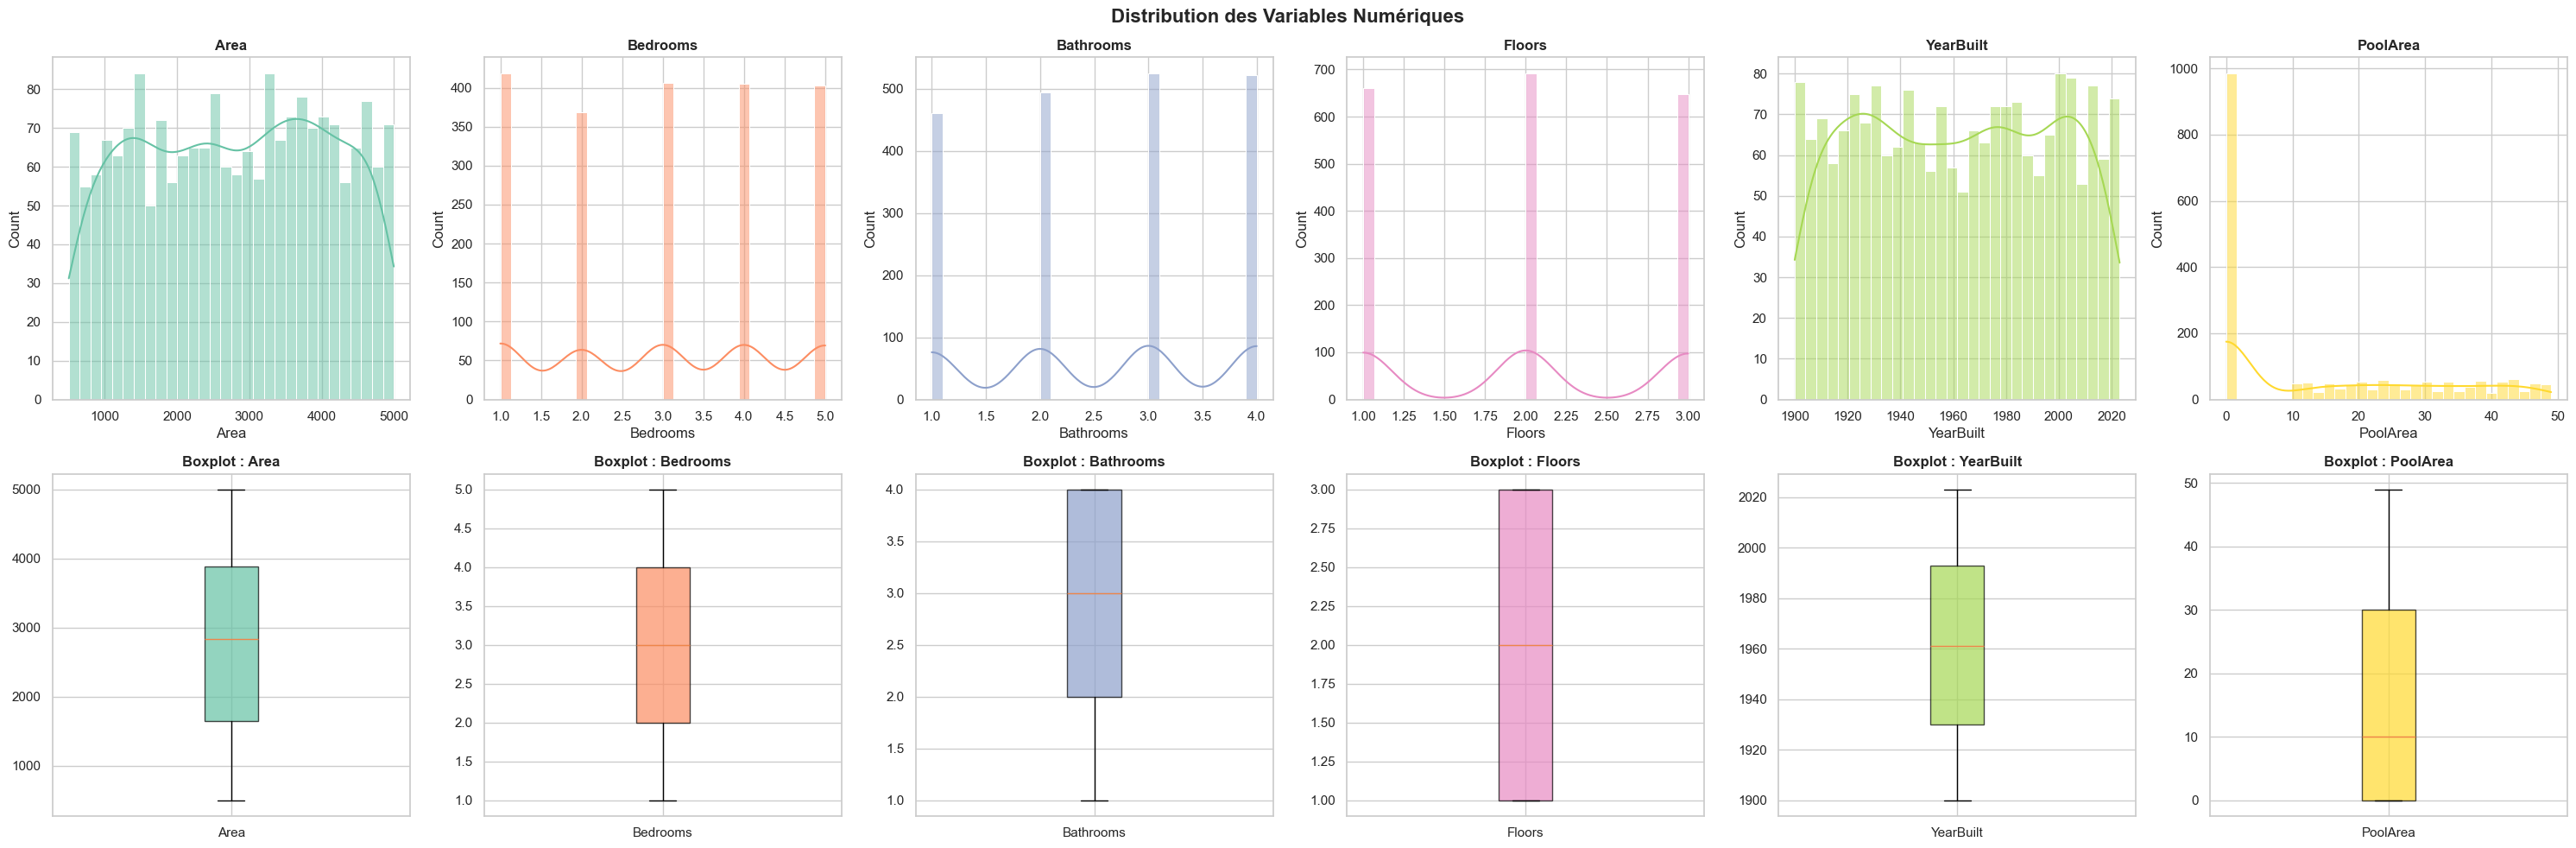

In [ ]:
features_num = [c for c in num_cols if c != 'Price']
n = len(features_num)

fig, axes = plt.subplots(2, n, figsize=(5*n, 10))
fig.suptitle('Distribution des Variables Numériques', fontsize=16, fontweight='bold')
colors = sns.color_palette('Set2', n)

for i, col in enumerate(features_num):
    # Histogramme
    sns.histplot(df[col], bins=30, kde=True, ax=axes[0, i], color=colors[i])
    axes[0, i].set_title(f'{col}', fontweight='bold')

    # Boxplot
    axes[1, i].boxplot(df[col].dropna(), patch_artist=True,
                       boxprops=dict(facecolor=colors[i], alpha=0.7))
    axes[1, i].set_title(f'Boxplot : {col}', fontweight='bold')
    axes[1, i].set_xticklabels([col])

plt.tight_layout()

plt.show()

Cette visualisation présente la distribution des principales variables explicatives.

Area : distribution assez uniforme avec une légère concentration autour des valeurs moyennes (≈ 2000–4000 m²). Quelques valeurs extrêmes apparaissent.

Bedrooms : variable discrète (1 à 5), avec une concentration autour de 3 et 4 chambres.

Bathrooms : distribution similaire, majoritairement entre 2 et 4 salles de bain.

Floors : valeurs discrètes (1 à 3 étages), avec une forte présence des maisons à 2 étages.

YearBuilt : distribution assez large (1900–2020), montrant une diversité de biens anciens et récents.

PoolArea : fortement asymétrique avec une majorité de valeurs à 0 → variable très sparse avec présence de quelques grandes valeurs (outliers).


Conclusion :

Données globalement propres mais mélange de variables continues et discrètes

Présence d’outliers (surtout PoolArea et Area)

Pool-related features très déséquilibrées

Certaines variables nécessitent normalisation ou encodage adapté

---
## 8. Analyse des Variables Catégorielles

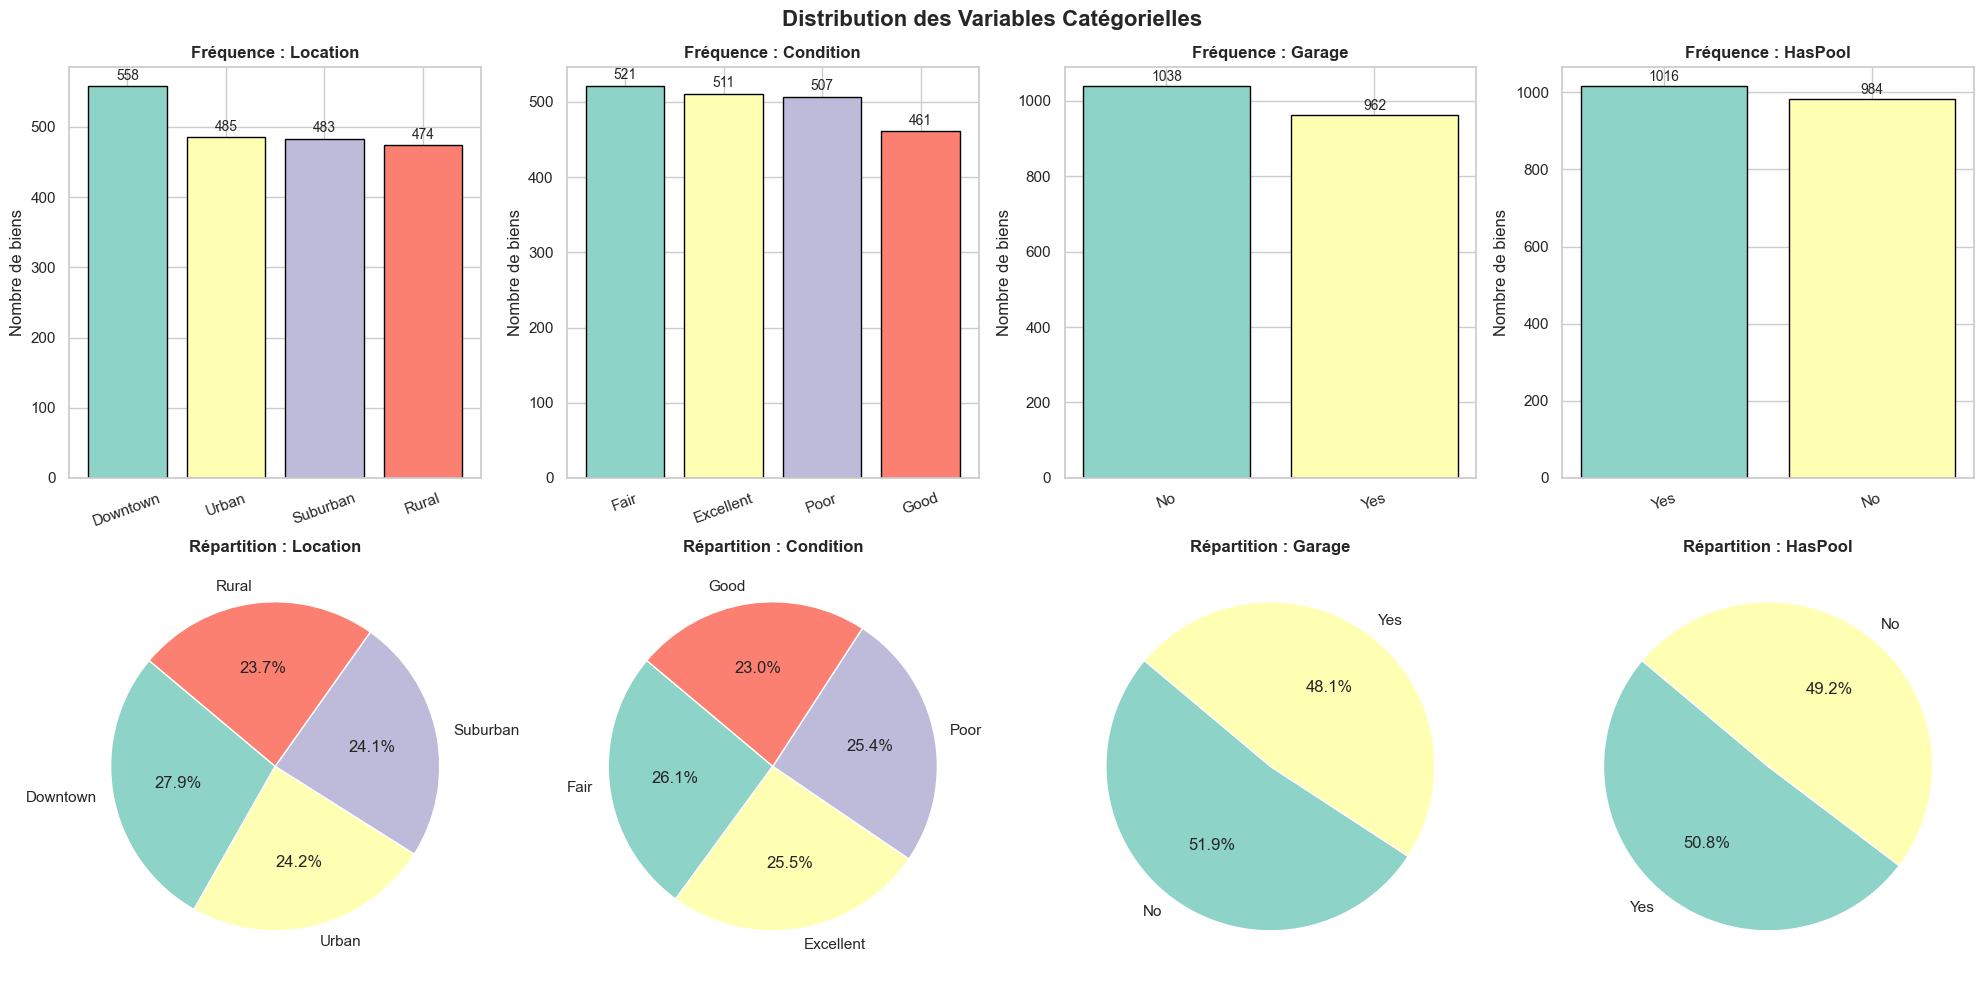

In [45]:
# On analyse uniquement les catégorielles principales (pas PoolQuality/PoolType séparément)
cat_main = ['Location', 'Condition', 'Garage', 'HasPool']

fig, axes = plt.subplots(2, len(cat_main), figsize=(5*len(cat_main), 10))
fig.suptitle('Distribution des Variables Catégorielles', fontsize=16, fontweight='bold')

for i, col in enumerate(cat_main):
    counts = df[col].value_counts()
    pal = sns.color_palette('Set3', len(counts))

    # Barplot
    axes[0, i].bar(counts.index, counts.values, color=pal, edgecolor='black')
    axes[0, i].set_title(f'Fréquence : {col}', fontweight='bold')
    axes[0, i].set_ylabel('Nombre de biens')
    axes[0, i].tick_params(axis='x', rotation=20)
    for bar, v in zip(axes[0, i].patches, counts.values):
        axes[0, i].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                        str(v), ha='center', va='bottom', fontsize=10)

    # Pie chart
    axes[1, i].pie(counts.values, labels=counts.index, autopct='%1.1f%%',
                   startangle=140, colors=pal)
    axes[1, i].set_title(f'Répartition : {col}', fontweight='bold')

plt.tight_layout()

plt.show()

Location est relativement équilibrée entre les différentes catégories (Downtown, Urban, Suburban, Rural), avec une légère dominance de Downtown (~27.9%).
Condition est également bien répartie entre Fair, Excellent, Poor et Good, sans déséquilibre majeur (≈ 23% à 26% pour chaque catégorie).
Garage montre une distribution presque équilibrée :

No : ~51.9%
Yes : ~48.1%

HasPool présente aussi un équilibre similaire :

Yes : ~50.8%
No : ~49.2%

 Conclusion :
Les variables catégorielles sont bien équilibrées, ce qui est très positif pour le Machine Learning.
Il n’y a pas de biais majeur lié à une catégorie dominante.
Ces variables sont pertinentes et peuvent être encodées (One-Hot Encoding) sans risque de déséquilibre.

 Biens avec piscine : 1016 (50.8%)



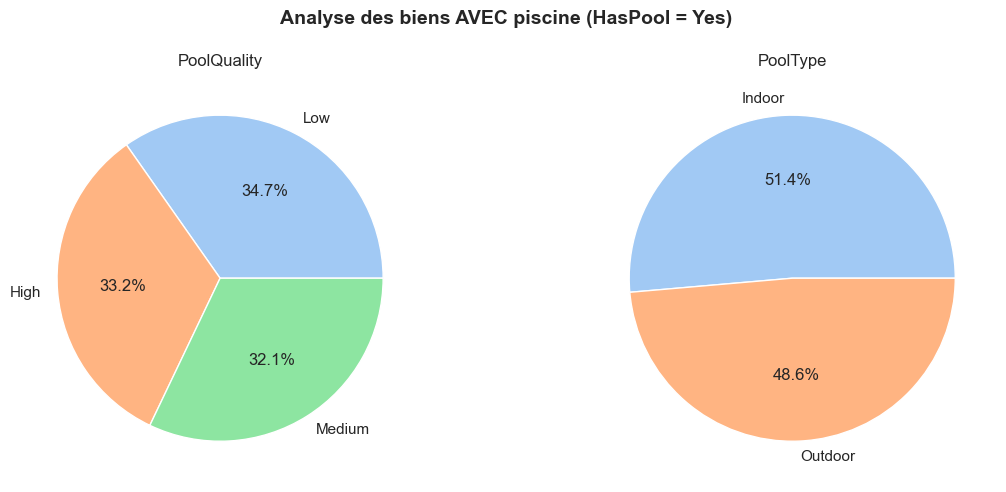

PoolQuality : {'Low': 353, 'High': 337, 'Medium': 326}
PoolType    : {'Indoor': 522, 'Outdoor': 494}


In [46]:
# Analyse PoolQuality et PoolType (uniquement biens avec piscine)
df_pool = df[df['HasPool'] == 'Yes'].copy()
print(f' Biens avec piscine : {len(df_pool)} ({len(df_pool)/len(df)*100:.1f}%)')
print()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Analyse des biens AVEC piscine (HasPool = Yes)', fontsize=14, fontweight='bold')

for i, col in enumerate(['PoolQuality', 'PoolType']):
    counts = df_pool[col].value_counts()
    axes[i].pie(counts.values, labels=counts.index, autopct='%1.1f%%',
                colors=sns.color_palette('pastel', len(counts)))
    axes[i].set_title(f'{col}')

plt.tight_layout()

plt.show()

print('PoolQuality :', df_pool['PoolQuality'].value_counts().to_dict())
print('PoolType    :', df_pool['PoolType'].value_counts().to_dict())

---
## 9. Analyse des Corrélations

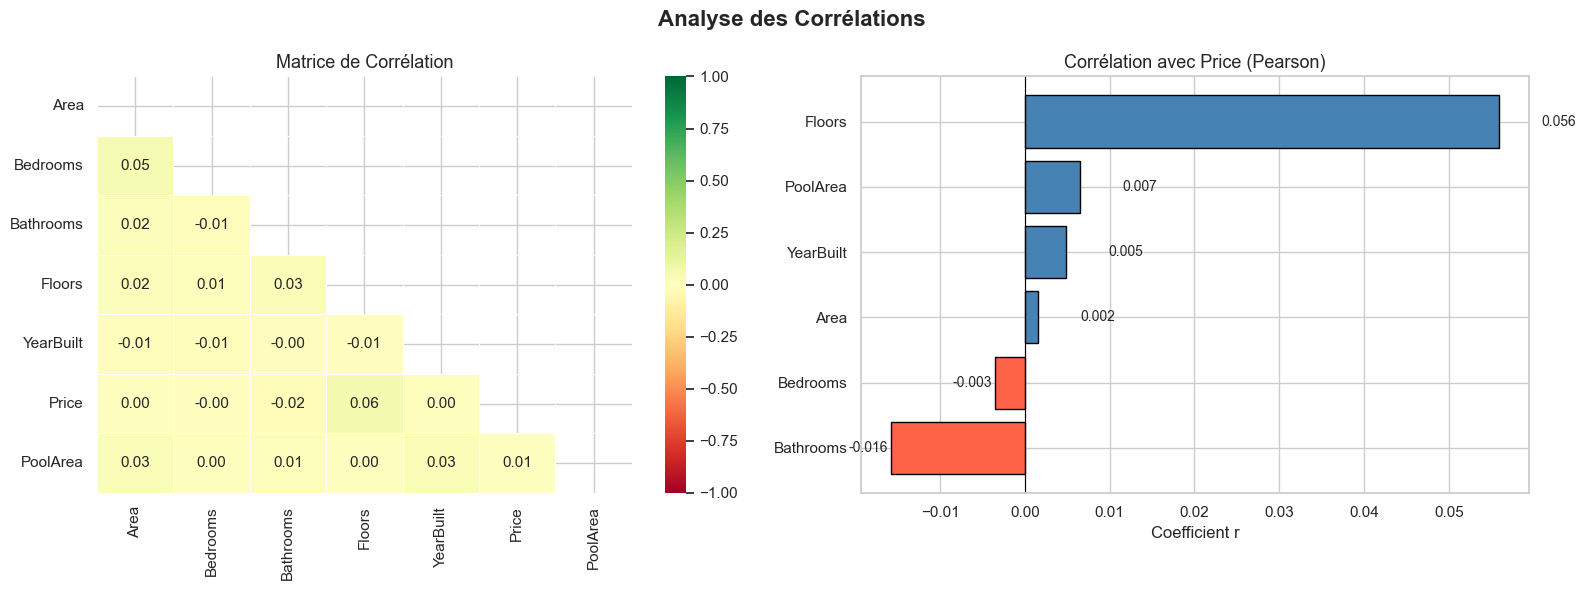


📌 Corrélations avec Price :
                  r
Floors     0.055890
PoolArea   0.006531
YearBuilt  0.004845
Area       0.001542
Bedrooms  -0.003471
Bathrooms -0.015737


In [ ]:
corr = df[num_cols].corr()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Analyse des Corrélations', fontsize=16, fontweight='bold')

# Heatmap triangulaire
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn',
            mask=mask, linewidths=0.5, vmin=-1, vmax=1, ax=axes[0],
            annot_kws={'size': 11})
axes[0].set_title('Matrice de Corrélation', fontsize=13)

# Corrélation avec Price
corr_price = corr['Price'].drop('Price').sort_values()
colors_bar = ['tomato' if v < 0 else 'steelblue' for v in corr_price.values]
axes[1].barh(corr_price.index, corr_price.values, color=colors_bar, edgecolor='black')
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_title('Corrélation avec Price (Pearson)', fontsize=13)
axes[1].set_xlabel('Coefficient r')
for i, (val, name) in enumerate(zip(corr_price.values, corr_price.index)):
    offset = 0.005 * (1 if val >= 0 else -1)
    axes[1].text(val + offset, i, f'{val:.3f}', va='center', fontsize=10)

plt.tight_layout()

plt.show()

print('\n Corrélations avec Price :')
print(corr_price.sort_values(ascending=False).to_frame('r').to_string())

GRAPHE 1
La matrice de corrélation permet d’analyser les relations linéaires entre les variables numériques.
Les corrélations entre les variables sont très faibles (proches de 0).

Exemple :
Area ↔ Bedrooms : ~0.05 (très faible)/
Bathrooms ↔ Bedrooms : ~ -0.01 /
Floors ↔ Price : ~0.06 (la plus élevée mais reste faible)/
Aucune corrélation forte (> 0.5) n’est observée.

Conclusion :

Les variables sont faiblement corrélées entre elles → pas de problème de multicolinéarité.
Le modèle devra capter des relations non linéaires ou combinées.
Une simple régression linéaire pourrait être limitée → intérêt d’essayer :
Random Forest
Gradient Boosting

GRAPHE 2
Ce graphique montre la corrélation de chaque variable avec le prix.
Résultats principaux :
Floors : corrélation la plus élevée (~0.056) → influence positive mais faible/
PoolArea : ~0.007 → très faible impact/
YearBuilt : ~0.005 → presque négligeable/
Area : ~0.002 → surprenant, relation très faible/
Bedrooms : ~ -0.003 → impact quasi nul/
Bathrooms : ~ -0.016 → légère corrélation négative/

Conclusion :
Aucune variable n’explique fortement le prix individuellement.
Le prix dépend probablement de combinaisons de variables.
Les relations ne sont pas purement linéaires.

---
## 10. Détection des Outliers

     DÉTECTION DES OUTLIERS (Méthode IQR)
  Area            :    0 outliers (0.0%)
  Bedrooms        :    0 outliers (0.0%)
  Bathrooms       :    0 outliers (0.0%)
  Floors          :    0 outliers (0.0%)
  YearBuilt       :    0 outliers (0.0%)
  Price           :    0 outliers (0.0%)
  PoolArea        :    0 outliers (0.0%)


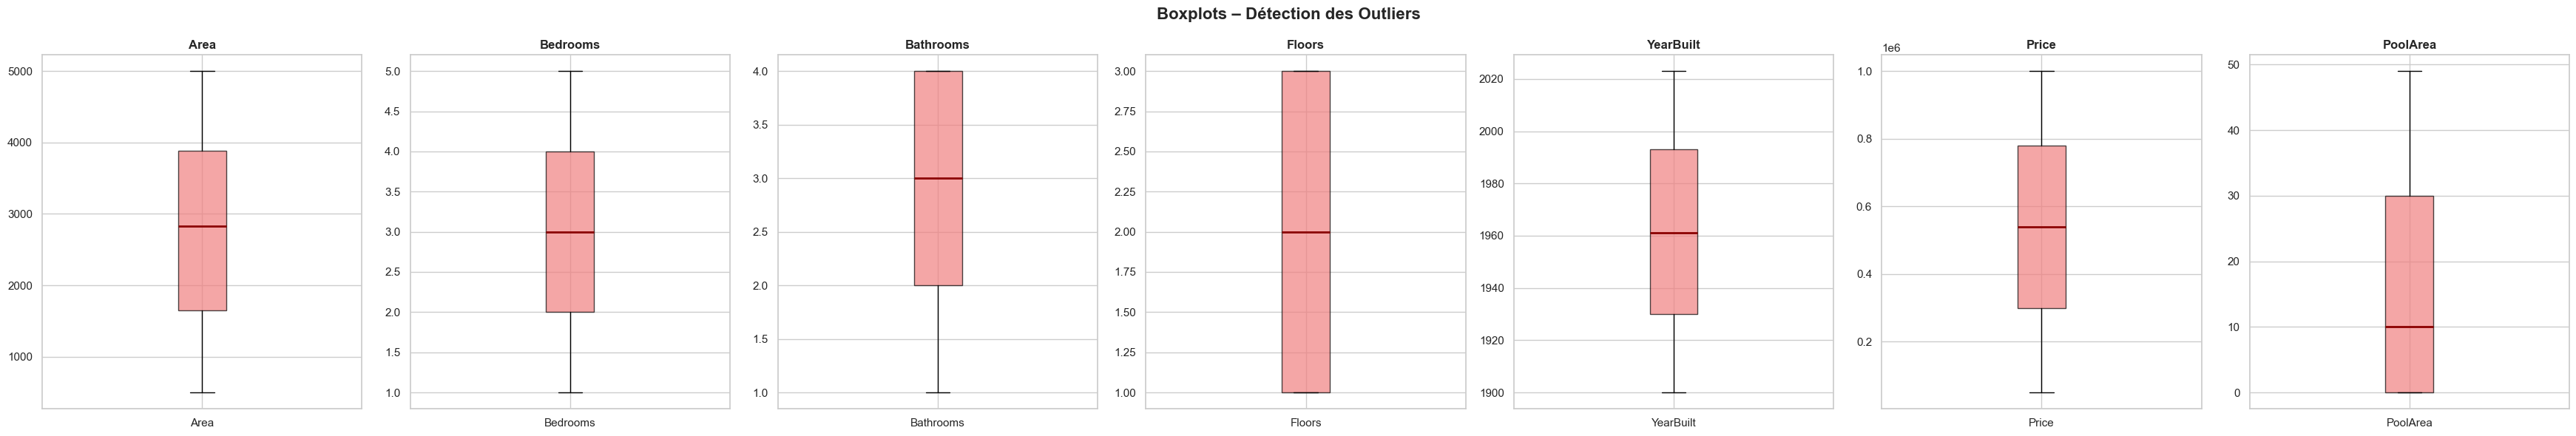

In [48]:
def outliers_iqr(series):
    Q1, Q3 = series.quantile(0.25), series.quantile(0.75)
    IQR = Q3 - Q1
    return series[(series < Q1 - 1.5*IQR) | (series > Q3 + 1.5*IQR)]

print('=' * 55)
print('     DÉTECTION DES OUTLIERS (Méthode IQR)')
print('=' * 55)
for col in num_cols:
    outs = outliers_iqr(df[col].dropna())
    pct = len(outs) / len(df) * 100
    print(f"  {col:<15} : {len(outs):>4} outliers ({pct:.1f}%)")

# Boxplots
fig, axes = plt.subplots(1, len(num_cols), figsize=(5*len(num_cols), 6))
fig.suptitle('Boxplots – Détection des Outliers', fontsize=16, fontweight='bold')

for i, col in enumerate(num_cols):
    ax = axes[i]
    ax.boxplot(df[col].dropna(), patch_artist=True,
               boxprops=dict(facecolor='lightcoral', alpha=0.7),
               flierprops=dict(marker='o', color='red', markersize=4, alpha=0.5),
               medianprops=dict(color='darkred', linewidth=2))
    ax.set_title(col, fontweight='bold')
    ax.set_xticklabels([col])

plt.tight_layout()

plt.show()

La détection des valeurs aberrantes via la méthode IQR montre :
0 outliers détectés (0.0%) pour toutes les variables :
Area,
Bedrooms,
Bathrooms,
Floors,
YearBuilt,
Price,
PoolArea

Les boxplots confirment que :
Les distributions sont globalement propres et bien contenues,
Pas de valeurs extrêmes perturbatrices

Conclusion :
Le dataset est propre → pas besoin de suppression d’outliers ,
Pas de risque de biais lié à des valeurs extrêmes,
Bon point pour la stabilité du modèle

---
## 11. Analyse Spéciale : Impact de la Piscine sur le Prix

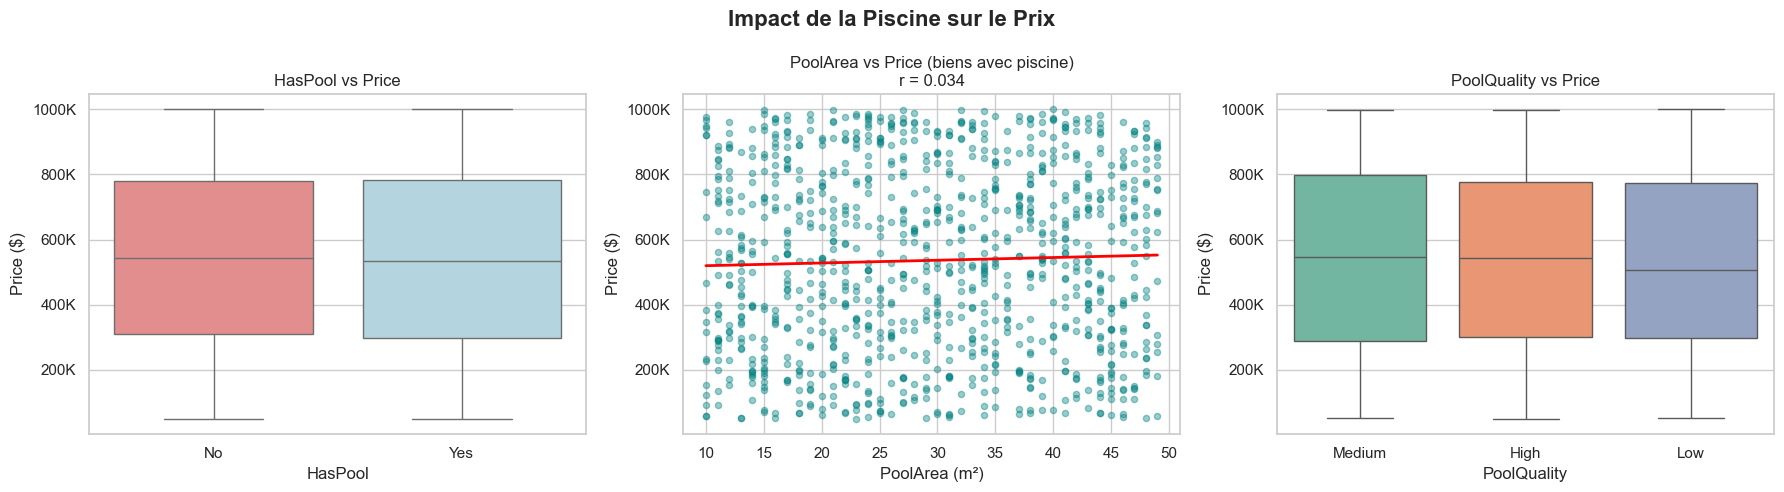

Prix moyen avec piscine    : $535,983
Prix moyen sans piscine    : $539,426
 Différence moyenne         : $-3,443

   T-test → t=-0.278, p=0.780743 → Non significative 


In [52]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Impact de la Piscine sur le Prix', fontsize=16, fontweight='bold')

# HasPool vs Price
sns.boxplot(data=df, x='HasPool', y='Price', palette=['lightcoral', 'lightblue'],
            order=['No', 'Yes'], ax=axes[0])
axes[0].set_title('HasPool vs Price')
axes[0].set_ylabel('Price ($)')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}K'))

# PoolArea vs Price (biens avec piscine)
df_p = df[df['HasPool'] == 'Yes']
axes[1].scatter(df_p['PoolArea'], df_p['Price'], alpha=0.4, s=20, color='teal')
m, b = np.polyfit(df_p['PoolArea'], df_p['Price'], 1)
x_l = np.linspace(df_p['PoolArea'].min(), df_p['PoolArea'].max(), 100)
axes[1].plot(x_l, m*x_l + b, color='red', linewidth=2)
r, p = stats.pearsonr(df_p['PoolArea'], df_p['Price'])
axes[1].set_title(f'PoolArea vs Price (biens avec piscine)\nr = {r:.3f}')
axes[1].set_xlabel('PoolArea (m²)')
axes[1].set_ylabel('Price ($)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}K'))

# PoolQuality vs Price
order_q = df_p.groupby('PoolQuality')['Price'].median().sort_values(ascending=False).index
sns.boxplot(data=df_p, x='PoolQuality', y='Price', order=order_q,
            palette='Set2', ax=axes[2])
axes[2].set_title('PoolQuality vs Price')
axes[2].set_ylabel('Price ($)')
axes[2].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}K'))

plt.tight_layout()

plt.show()

# Comparaison moyenne
print('Prix moyen avec piscine    :', f"${df[df['HasPool']=='Yes']['Price'].mean():,.0f}")
print('Prix moyen sans piscine    :', f"${df[df['HasPool']=='No']['Price'].mean():,.0f}")
diff = df[df['HasPool']=='Yes']['Price'].mean() - df[df['HasPool']=='No']['Price'].mean()
print(f' Différence moyenne         : ${diff:,.0f}')

# T-test
g1 = df[df['HasPool']=='Yes']['Price']
g2 = df[df['HasPool']=='No']['Price']
t, p = stats.ttest_ind(g1, g2)
print(f'\n   T-test → t={t:.3f}, p={p:.6f}',
      '→ Différence significative ' if p < 0.05 else '→ Non significative ')

Résumé de l’analyse (Impact de la piscine sur le prix)
Présence de piscine (HasPool) : aucune différence significative des prix entre les maisons avec ou sans piscine.
Surface de la piscine (PoolArea) : corrélation très faible avec le prix (r ≈ 0.034), donc impact négligeable.
Qualité de la piscine (PoolQuality) : pas d’effet clair sur le prix, les distributions sont très proches.


Conclusion :


Les variables liées à la piscine (présence, surface, qualité) montrent une faible corrélation avec le prix, ce qui suggère qu’elles ne sont pas des facteurs déterminants dans la prédiction du prix immobilier dans ce dataset.

**Résumé global de l’EDA (Conclusion finale)**

L’analyse exploratoire des données (EDA) du dataset immobilier permet de tirer les conclusions suivantes :

  **Points positifs**
Les données sont propres avec très peu de valeurs manquantes globalement.
Les variables catégorielles (Location, Condition, Garage, HasPool) sont bien équilibrées, donc exploitables pour le Machine Learning.
Aucune corrélation forte entre variables → pas de multicolinéarité.
Aucun outlier significatif détecté → dataset stable.


   **Points importants observés**
La variable cible Price n’est pas normalement distribuée → une transformation (log) peut améliorer la modélisation.
Les variables individuelles (Area, Bedrooms, PoolArea, etc.) ont une très faible corrélation avec le prix.
Les variables liées à la piscine ont un impact quasi nul sur le prix.
Les relations semblent non linéaires.


   **Conclusion globale**
Le prix immobilier ne dépend pas d’une seule variable, mais plutôt de combinaisons complexes de facteurs.